In [1]:
from dotenv import load_dotenv
load_dotenv()

import os

import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

from pixell import colorize
colorize.mpl_register("planck")

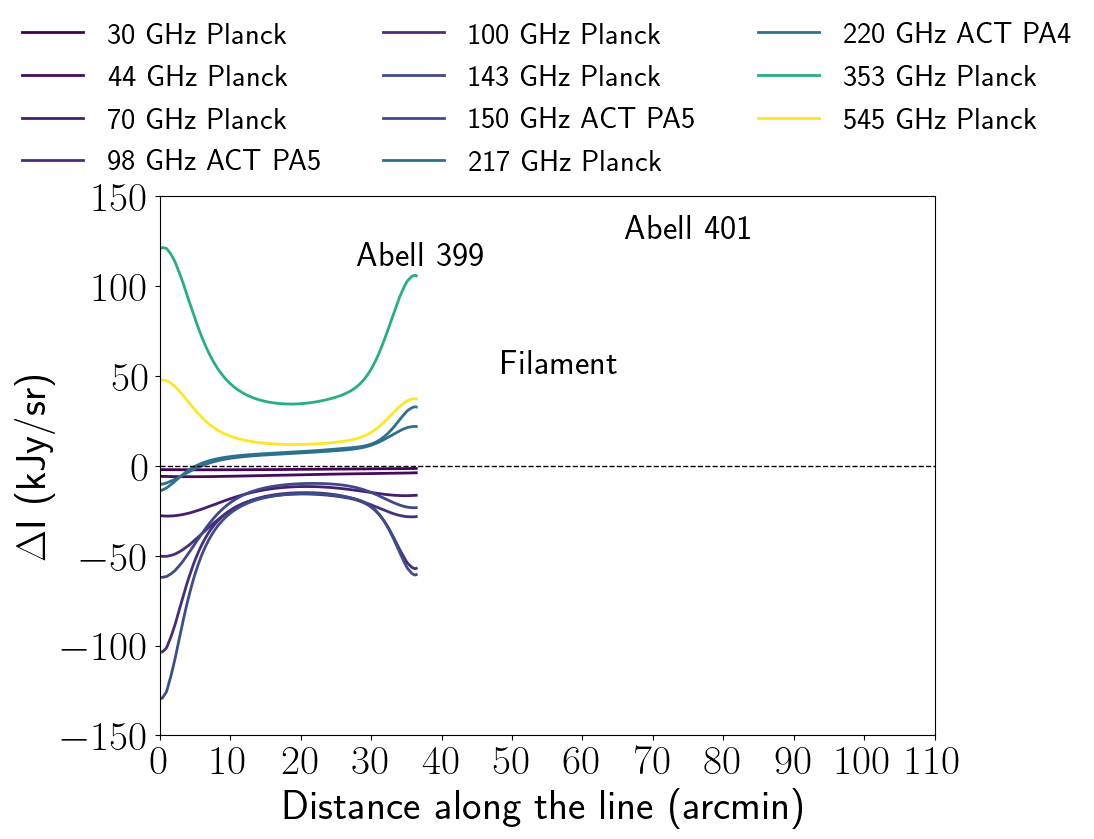

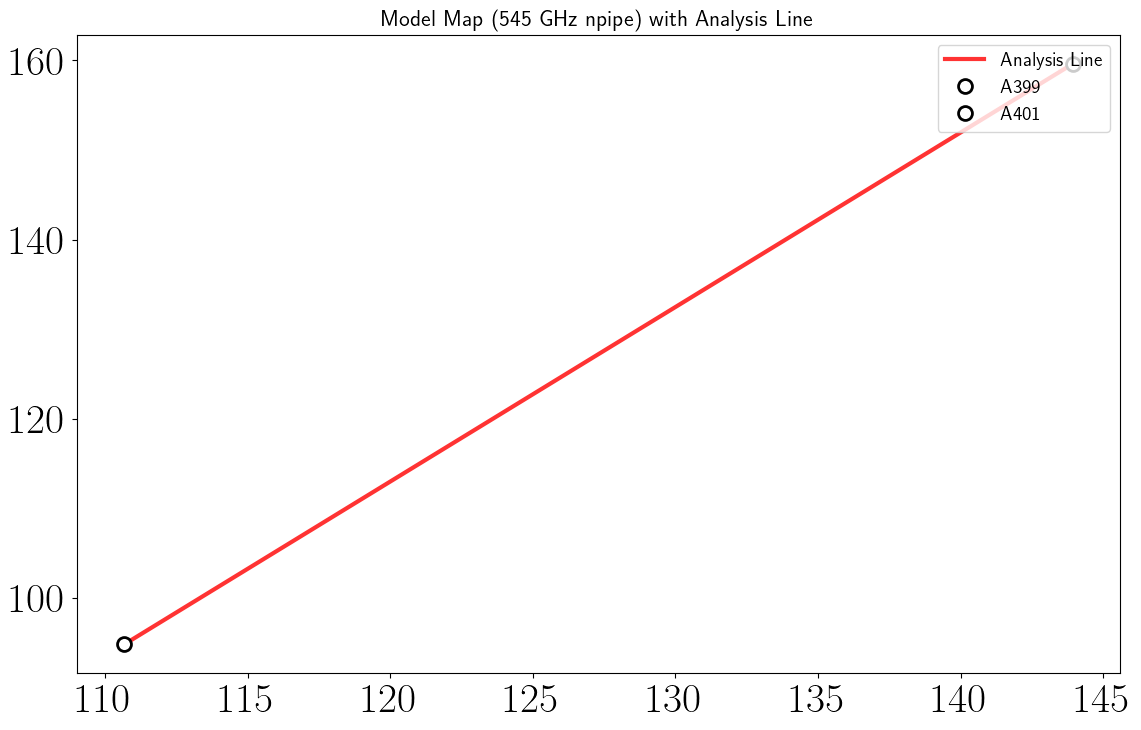

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.coordinates import SkyCoord
from astropy import units as u
from pixell import enmap
from scipy.interpolate import RectBivariateSpline
import glob

# matplotlib latex font sans-serif with fontsize 25
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=30)

# Define cluster coordinates (from the fit results)
ra_c2_fit =  45.0297210 # A401 RA
dec_c2_fit = 14.1640347  # A401 Dec
ra_c1_fit = 44.1817592   # A399 RA  
dec_c1_fit = 12.4640926  # A399 Dec


ra_c2_fit =  44.464 # A401 RA
dec_c2_fit = 13.04  # A401 Dec
ra_c1_fit = 44.741   # A399 RA  
dec_c1_fit = 13.580  # A399 Dec


# Create line connecting the two clusters
n_points = 10000
ra_line = np.linspace(ra_c1_fit, ra_c2_fit, n_points)
dec_line = np.linspace(dec_c1_fit, dec_c2_fit, n_points)

# Find all model files in the directory
model_dir = "/home/gill/research/ACT/paper/models/indiv/sep29/full_model/models/"
model_files = glob.glob(os.path.join(model_dir, "bridge_indv_*_model_Jy.fits"))
model_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

# Extract frequencies and arrays from filenames
freq_data = []
for file in model_files:
    basename = os.path.basename(file)
    # Extract frequency and array info from filename
    # Expected format: bridge_indv_98_pa5_model_Jy.fits
    parts = basename.split('_')
    if len(parts) >= 3:
        freq = parts[2]  # frequency part
        array = parts[3] if len(parts) > 3 else ""  # array part
        freq_data.append((file, freq, array))

# Extract signal along the line for each frequency
signal_data = {}
frequency_values = []  # Store numerical frequency values for color mapping
distance_arcmin = np.sqrt((ra_c2_fit - ra_c1_fit)**2 + (dec_c2_fit - dec_c1_fit)**2) * 60

for model_file, freq, array in freq_data:
    # Load the model

    if (array in ["pa4"] and freq == "150"):
        continue

    if "pa6" in array:
        continue

    model_map = enmap.read_map(model_file) / 1e3 # convert to kJy/sr
    
    # Create frequency label
    freq_label = f"{freq} GHz {array}" if array else f"{freq} GHz"
    
    # Store numerical frequency value for color mapping
    frequency_values.append(float(freq))
    
    # Extract signal along the line
    y_coords = np.arange(model_map.shape[0])
    x_coords = np.arange(model_map.shape[1])
    interpolator = RectBivariateSpline(y_coords, x_coords, model_map, kx=1, ky=1)
    
    signal_along_line = []
    for ra, dec in zip(ra_line, dec_line):
        # Convert world coordinates to pixel coordinates
        pix_coords = model_map.sky2pix([dec * np.pi/180, ra * np.pi/180])
        
        # Use interpolation
        if (0 <= pix_coords[0] < model_map.shape[0] and 
            0 <= pix_coords[1] < model_map.shape[1]):
            pix_val = interpolator(pix_coords[0], pix_coords[1])[0, 0]
        else:
            pix_val = 0.0
        
        signal_along_line.append(pix_val)
    
    # Store signal data
    signal_data[freq_label] = np.array(signal_along_line)
    
# Create combined plot of all signals along the line
distance = np.linspace(0, distance_arcmin, n_points)
plt.figure(figsize=(10, 7))

# Create color mapping based on frequency values
frequency_values = np.array(frequency_values)
freq_norm = plt.Normalize(vmin=frequency_values.min(), vmax=frequency_values.max())
colormap = plt.cm.viridis

# Plot each signal with color based on frequency value
for i, (freq_label, signal) in enumerate(signal_data.items()):
    freq_val = frequency_values[i]
    color = colormap(freq_norm(freq_val))

    if "pa5" in freq_label:
        freq_label = freq_label.replace("pa5", "ACT PA5")
    elif "pa4" in freq_label:
        freq_label = freq_label.replace("pa4", "ACT PA4")
    elif "npipe" in freq_label:
        freq_label = freq_label.replace("npipe", "Planck")

    plt.plot(distance, signal, linewidth=2, color=color, label=freq_label)

plt.xlabel('Distance along the line (arcmin)')
plt.ylabel('$\Delta$I (kJy/sr)')

# Add text labels for regions
plt.text(37, 125, 'Abell 399', ha='center', va='top', fontsize=25, weight='bold')
plt.text(75, 140, 'Abell 401', ha='center', va='top', fontsize=25, weight='bold')
plt.text(57, 65, 'Filament', ha='center', va='top', fontsize=25, weight='bold')

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.legend(fontsize=22, loc='upper center', ncols=3, frameon=False, bbox_to_anchor=(0.5, 1.375))
plt.ylim(-150, 150)
plt.yticks(np.arange(-150, 151, 50))

plt.xlim(0, 110)
plt.xticks(np.arange(0, 111, 10))
plt.savefig("../plots/signal_along_line_all_frequencies_sep29.pdf", bbox_inches='tight', dpi=300)
plt.show()

# show the figure with the line as well
# Create a figure showing one of the maps with the line overlaid
plt.figure(figsize=(12, 8))

# Use the last loaded model map for visualization
plot_map = model_map.copy()

# Create the plot
plot = enplot.plot(plot_map, colorbar=True, ticks=5, grid=True)

# Convert the line coordinates to pixel coordinates for plotting
line_pix_coords = []
for ra, dec in zip(ra_line, dec_line):
    pix_coords = plot_map.sky2pix([dec * np.pi/180, ra * np.pi/180])
    line_pix_coords.append([pix_coords[1], pix_coords[0]])  # x, y order for plotting

line_pix_coords = np.array(line_pix_coords)

# Overlay the line on the map
plt.plot(line_pix_coords[:, 0], line_pix_coords[:, 1], 'r-', linewidth=3, alpha=0.8, label='Analysis Line')

# Mark the cluster positions
cluster1_pix = plot_map.sky2pix([dec_c1_fit * np.pi/180, ra_c1_fit * np.pi/180])
cluster2_pix = plot_map.sky2pix([dec_c2_fit * np.pi/180, ra_c2_fit * np.pi/180])

plt.plot(cluster1_pix[1], cluster1_pix[0], 'wo', markersize=10, markeredgecolor='black', markeredgewidth=2, label='A399')
plt.plot(cluster2_pix[1], cluster2_pix[0], 'wo', markersize=10, markeredgecolor='black', markeredgewidth=2, label='A401')

plt.legend(fontsize=14, loc='upper right')
plt.title(f'Model Map ({freq} GHz {array}) with Analysis Line', fontsize=16)
plt.tight_layout()
plt.savefig("../plots/model_map_with_line_sep29.pdf", bbox_inches='tight', dpi=300)
plt.show()

